Тема: Застосування методу множинної лінійної регресії в задачах передбачування системного аналізу даних.

In [1]:
import numpy as np
import pandas as pd
pd.options.mode.chained_assignment = None

import matplotlib.pyplot as plt
import seaborn as sns
sns.set(font_scale=1.3, palette='Set2')

# обратите внимание, что Scikit-Learn импортируется как sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn import metrics

In [2]:
data = pd.read_csv('./insurance_miptstats.csv', parse_dates=[0])
data.head()

,birthday,sex,bmi,children,smoker,region,charges
0,2001-12-20,female,27.900,0,yes,southwest,16884.92400
1,2003-03-18,male,33.770,1,no,southeast,1725.55230
2,1992-11-02,male,33.000,3,no,southeast,4449.46200
3,1987-07-27,male,22.705,0,no,northwest,21984.47061
4,1988-11-04,male,28.880,0,no,northwest,3866.85520


In [3]:
data.shape

(1338, 7)

In [4]:
train, test = train_test_split(data, test_size=0.2)
train.shape, test.shape

((1070, 7), (268, 7))

In [11]:
# Обчислення віку у повних роках
train['age'] = ((pd.Timestamp('2021-04-17') - train['birthday']).dt.days) // 365
test['age'] = ((pd.Timestamp('2021-04-17') - test['birthday']).dt.days) // 365

In [12]:
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler

# Вибираємо ознаки та цільову змінну
X_train = train[['age', 'bmi', 'children']]  # заміни на свої змінні
y_train = train['charges']  # заміни на свою цільову
X_test = test[['age', 'bmi', 'children']]
y_test = test['charges']

# Масштабуємо ознаки
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Створюємо і тренуємо нейромережу
mlp = MLPRegressor(hidden_layer_sizes=(50,), max_iter=1000, random_state=42)
mlp.fit(X_train_scaled, y_train)

# Прогнозування
y_pred_nn = mlp.predict(X_test_scaled)

# Отримання ваг (коефіцієнтів)
weights = mlp.coefs_[0].flatten()
print("Ваги (коефіцієнти):")
print(weights)

Ваги (коефіцієнти):
[ 7.35498401e+00  1.48862810e-01  3.66355707e-02  7.43472058e+00
  7.30797970e+00 -5.60666508e-02 -3.13488483e-02  7.71609908e+00
  6.63781450e-03 -1.05799870e-03  5.07197362e+00  7.61157824e+00
  7.73302048e+00 -3.21940027e-02 -4.46378882e+00  6.97150648e+00
  5.42313603e+00  7.35486828e+00  7.64520463e+00  7.35869833e+00
  7.59869441e+00 -5.45254928e+00  7.18625952e-03  7.23830130e+00
  1.29431239e-03  1.06983970e-01  7.10189909e+00  7.66751234e+00
  7.31763148e+00 -4.19614094e+00  7.33333882e+00  6.42924595e+00
  7.13729347e+00  7.97727750e+00  1.24004633e-01  7.48077692e+00
  7.22336764e+00 -7.39248993e-02  7.49146253e+00 -9.68389447e-03
 -5.10701365e+00  7.21178585e+00  6.94571702e+00  7.64884275e+00
 -3.27537906e-02  7.34417623e+00  7.42913025e+00  7.38995948e+00
  7.29020595e+00  6.69485097e+00  7.59356163e+00  2.82564326e-02
  1.15457263e-01  7.13568217e+00  7.22966884e+00  6.36242103e-02
 -2.16280186e-02  6.96025375e+00 -1.27379492e-01 -3.17234398e-04
 -1.2

C:\Users\porsh\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


In [13]:
categorial_features = ['sex', 'smoker', 'region']  # категоріальні ознаки
real_features = ['age', 'bmi', 'children']  # вещественные ознаки
target_feature = 'charges'  # ціоьова ознака

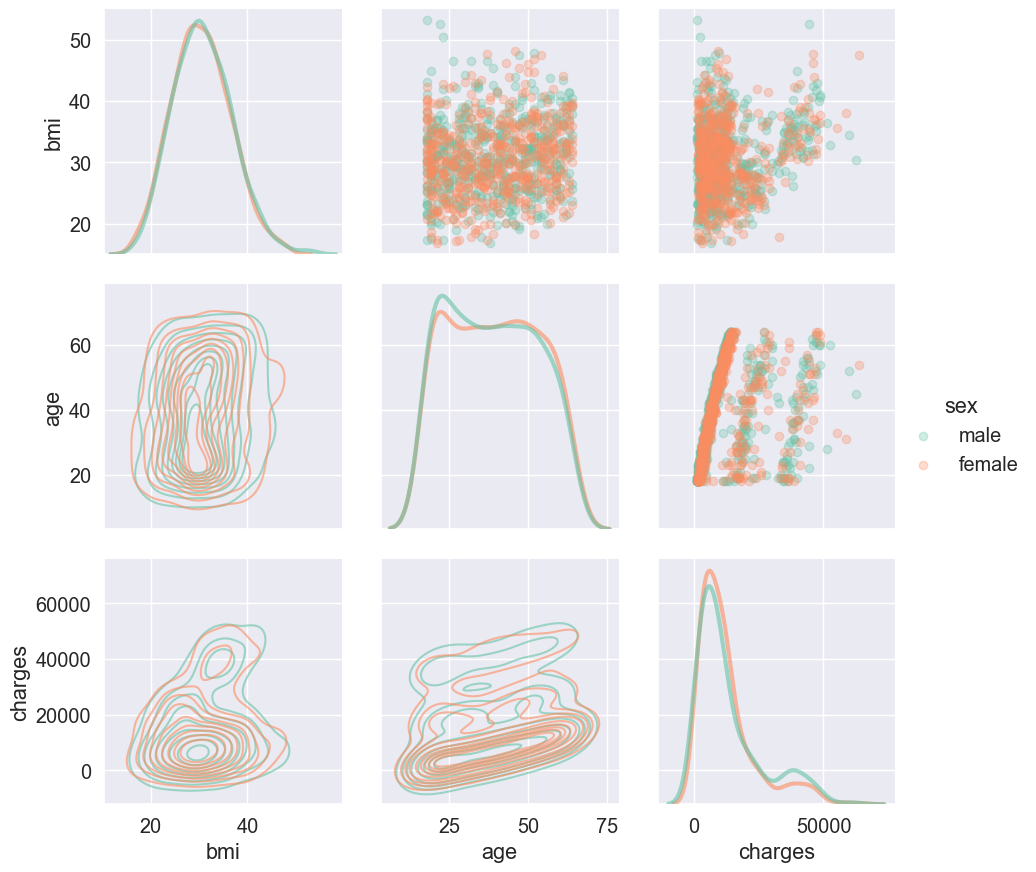

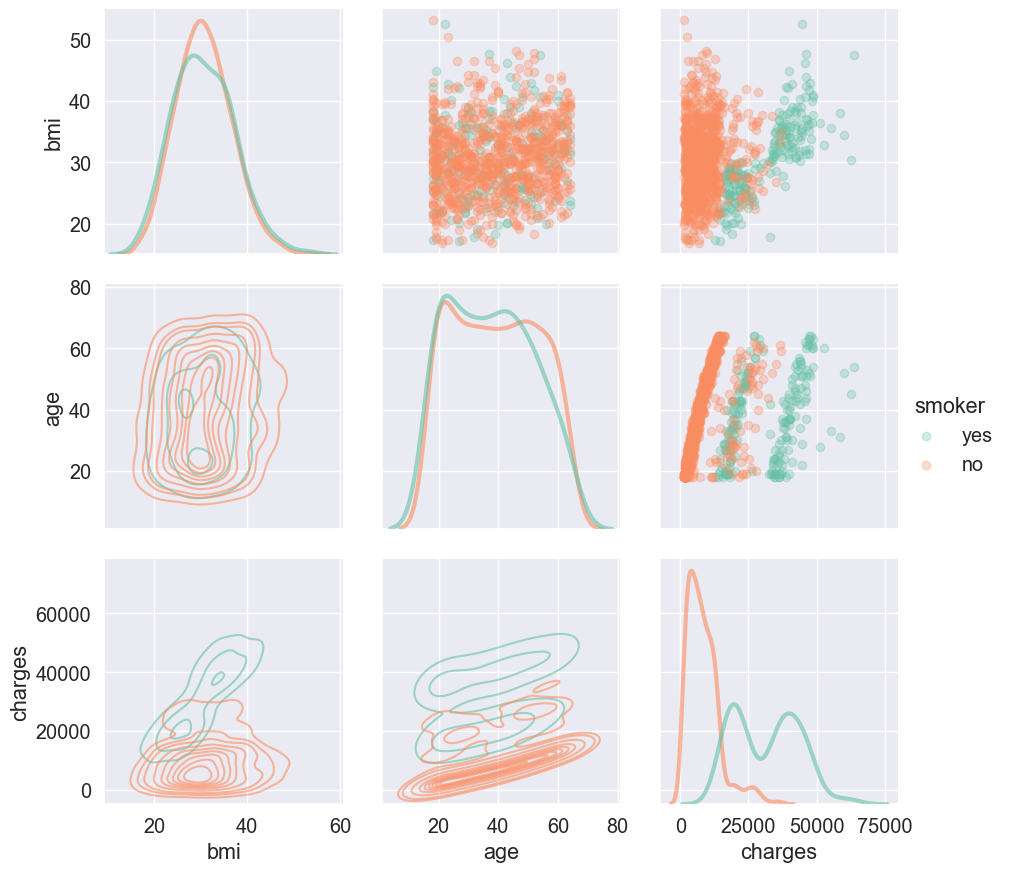

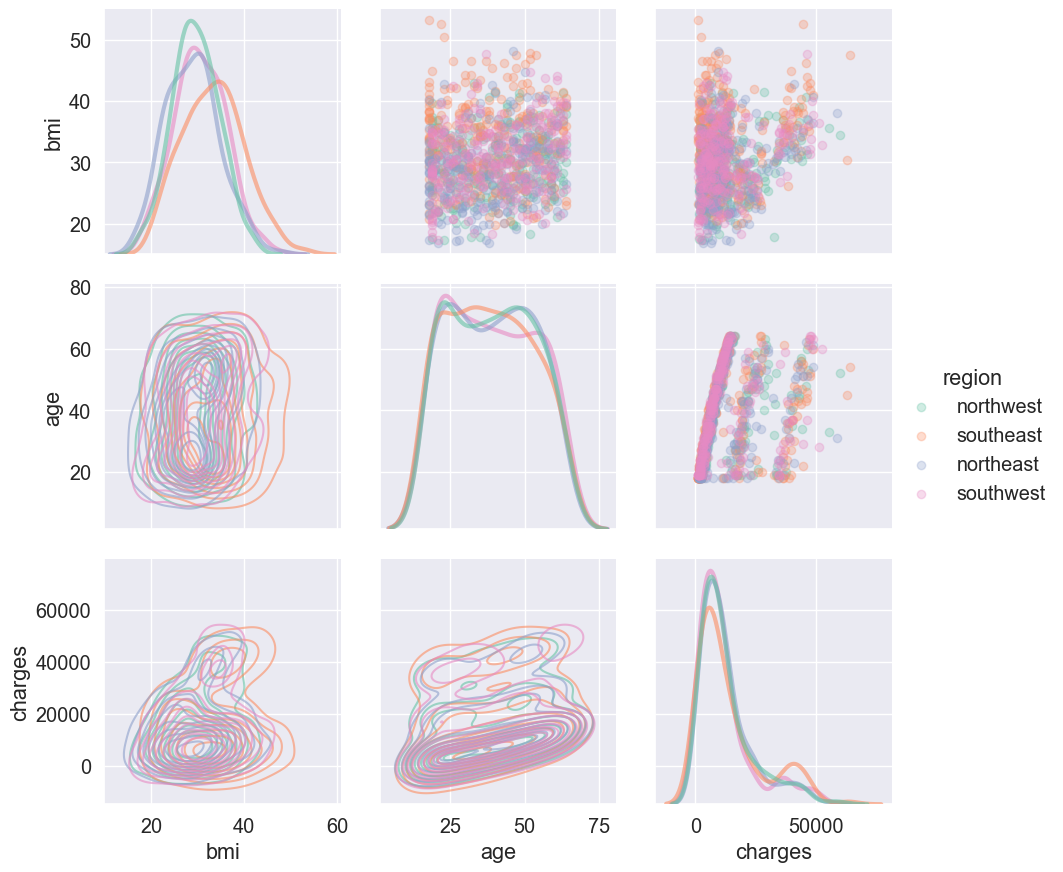

In [14]:
for hue in categorial_features:
    g = sns.PairGrid(train[['bmi', 'age', 'charges', hue]], 
                     hue=hue, diag_sharey=False, height=3)
    
    g.map_lower(sns.kdeplot, alpha=0.6)
    g.map_upper(plt.scatter, alpha=0.3)
    g.map_diag(sns.kdeplot, lw=3, alpha=0.6, 
               common_norm=False)  # кожна щільність окремо повинна давати 1 при інтегруванні
    
    g.add_legend()

In [16]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(drop='first', sparse_output=False)  # правильний параметр
train_cat = encoder.fit_transform(train[categorial_features])
train_cat

array([[1., 1., 1., 0., 0.],
       [1., 0., 0., 1., 0.],
       [0., 1., 1., 0., 0.],
       ...,
       [1., 0., 0., 0., 1.],
       [0., 0., 0., 0., 1.],
       [1., 1., 0., 1., 0.]])

In [17]:
encoder.categories_

[array(['female', 'male'], dtype=object),
 array(['no', 'yes'], dtype=object),
 array(['northeast', 'northwest', 'southeast', 'southwest'], dtype=object)]

In [18]:
X_train = np.hstack([train[real_features], train_cat])
X_train.shape

(1070, 8)

In [19]:
model = LinearRegression(fit_intercept=True)  # ініціалізуємо модель
model.fit(X_train, train[target_feature])  # навчаємо модель

LinearRegression()

In [20]:
model.coef_

array([  259.17833206,   346.74669687,   467.02304304,  -141.24238868,
       23763.30156585,  -291.55570105, -1189.83343814, -1013.83123068])

In [21]:
model.intercept_

-12164.76100812878

In [23]:
# Отримання віку клієнта по даті народження
test['age'] = ((pd.Timestamp('2021-04-17') - test['birthday']).dt.days) // 365

# Кодування категоріальних ознак за допомогою методу transform раніше навченого кодувальника
test_cat = encoder.transform(test[categorial_features])

# Поєднання даних
X_test = np.hstack([test[real_features], test_cat])

In [24]:
test_preds = model.predict(X_test)

In [25]:
test['age']

513    19
974    26
258    51
288    59
573    62
       ..
943    19
597    35
547    54
699    23
312    43
Name: age, Length: 268, dtype: int64

In [26]:
print(test_preds)

[ 2145.65326656  5524.56780182 10954.44861348 40105.22750279
 17152.40186933  8644.0045416  28670.21156649  8760.87671879
 13159.27381488  5173.47194739  6444.84596531 35758.44327586
  3532.64005405  9820.69256434  9282.94723967  7376.91668149
  3127.87992579 15263.78908327 33618.27896235 12018.31652491
 39946.15599645 31078.05838209  7890.1438593   8742.8017051
 10527.69981062  8824.76221777 38602.65607277 12165.62457568
 10390.45508613 29757.33417534   892.65203585 13752.80833623
  9279.7936083  10174.12882156 37545.52884873  3244.797213
  8857.25396875 -2106.71613765 13021.87215542 33253.10988061
 31738.08992231  4584.07908707  9961.74837035 10951.72266095
  6368.01480315  7848.84818968 37216.68305391  7876.88066072
  6147.90294822 33857.67814265 11386.02049367  8449.50026662
 11526.9284344   5082.387003   10193.2808496   4635.83716605
 11359.00647023 10372.63070844  6719.53989286  9791.70666912
 13401.19577181 17523.66620858  7167.79238876  7361.23655576
 10615.14915187 39341.67245

In [27]:
np.sqrt(((test[target_feature] - test_preds) ** 2).mean())

5620.604992553144

In [28]:
metrics.mean_squared_error(test[target_feature], test_preds) ** 0.5

5620.604992553144

In [29]:
metrics.mean_absolute_error(test[target_feature], test_preds)

4162.902101819814

In [30]:
def mean_absolute_percentage_error(y_true, y_pred):
    return 100 * (np.abs(y_true - y_pred) / y_true).mean()

In [31]:
mean_absolute_percentage_error(test[target_feature], test_preds)

41.8650022810341

In [32]:
train_preds = model.predict(X_train)

metrics.mean_squared_error(train[target_feature], train_preds) ** 0.5, \
metrics.mean_absolute_error(train[target_feature], train_preds), \
mean_absolute_percentage_error(train[target_feature], train_preds)

(6144.757206506953, 4207.934954145708, 42.740435551338386)

In [33]:
coef_age = model.coef_[real_features.index('age')]
print(coef_age)
coef_bmi = model.coef_[real_features.index('bmi')]
print(coef_bmi)

259.1783320601971
346.746696871684


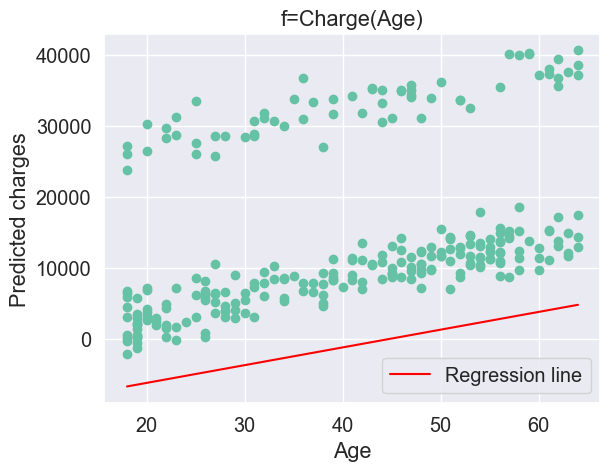

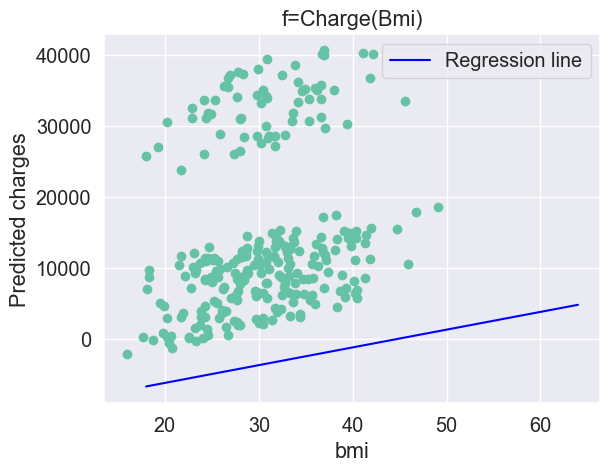

In [34]:
# Визначаємо коефіцієнти лінійної регресії
slope, intercept = model.coef_[0], model.intercept_
slope_bmi, intercept = model.coef_[1], model.intercept_

# Створення масиву значень ознаки age, для того щоб на його ознаці отримати прогнози цільової змінної
x = np.linspace(test['age'].min(), test['age'].max(), 100)
x_bmi = np.linspace(test['bmi'].min(), test['bmi'].max(), 100)

# Обчислюємо передбачення значення цільової змінної для кожного значення ознаки `age`
y = slope * x + intercept
y = slope_bmi * x_bmi + intercept

# Побудова графіків точкової діаграми і ліній регресій
#Графік залежності витрат на мед. витрати в залежності від віку
plt.scatter(test['age'], test_preds)
plt.plot(x, y, color='r', label='Regression line')
plt.title('f=Charge(Age)')
plt.xlabel('Age')
plt.ylabel('Predicted charges')
plt.legend()
plt.show()
#Графік залежності витрат на мед. витрати в залежності від індексу маси тіла
plt.scatter(test['bmi'], test_preds)
plt.plot(x, y, color='b', label='Regression line')
plt.title('f=Charge(Bmi)')
plt.xlabel('bmi')
plt.ylabel('Predicted charges')
plt.legend()
plt.show()